In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 12


In [ ]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Target variable: Survived")
print(df["Survived"].value_counts())

Target variable: Survived
Survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
survival_percentage = df["Survived"].value_counts(normalize=True) * 100
print(survival_percentage)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [ ]:
train_size = int(0.8 * len(df))

train_data = df.iloc[:train_size].copy()
test_data = df.iloc[train_size:].copy()

print("Training data:", train_data.shape)
print("Testing data:", test_data.shape)

Training data: (712, 12)
Testing data: (179, 12)


In [ ]:
print("Missing values in training data:")
print(train_data.isnull().sum())

Missing values in training data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            147
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          550
Embarked         1
dtype: int64


In [ ]:
print("Missing values in testing data:")
print(test_data.isnull().sum())

Missing values in testing data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             30
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          137
Embarked         1
dtype: int64


In [ ]:
print(train_data["Cabin"].isnull().sum())
print(test_data["Cabin"].isnull().sum())

550
137


In [ ]:
print("Cabin missing percentage:")
print(train_data["Cabin"].isnull().mean() * 100)

Cabin missing percentage:
77.24719101123596


In [ ]:
train_data = train_data.drop("Cabin", axis=1)
test_data = test_data.drop("Cabin", axis=1)

In [ ]:
print(train_data.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [ ]:
age_median = train_data["Age"].median()

print("Age median:", age_median)

Age median: 28.0


In [ ]:
train_data["Age"] = train_data["Age"].fillna(age_median)
test_data["Age"] = test_data["Age"].fillna(age_median)

In [ ]:
print("Training Age missing:", train_data["Age"].isnull().sum())
print("Testing Age missing:", test_data["Age"].isnull().sum())

Training Age missing: 0
Testing Age missing: 0


In [ ]:
embarked_mode = train_data["Embarked"].mode()[0]

print("Most frequent Embarked value:", embarked_mode)

Most frequent Embarked value: S


In [ ]:
train_data["Embarked"] = train_data["Embarked"].fillna(embarked_mode)
test_data["Embarked"] = test_data["Embarked"].fillna(embarked_mode)

In [ ]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
columns_to_remove = ["PassengerId", "Name", "Ticket"]

train_data = train_data.drop(columns=columns_to_remove)
test_data = test_data.drop(columns=columns_to_remove)

In [ ]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
print("Remaining columns:")
print(train_data.columns.tolist())

print("\nTraining shape:", train_data.shape)
print("Testing shape:", test_data.shape)

Remaining columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Training shape: (712, 8)
Testing shape: (179, 8)


In [ ]:
print("Current training columns:")
print(train_data.columns.tolist())

print("\nCurrent testing columns:")
print(test_data.columns.tolist())

Current training columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Current testing columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [ ]:
print("Missing values in training data:")
print(train_data.isnull().sum())

print("\nMissing values in testing data:")
print(test_data.isnull().sum())

Missing values in training data:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Missing values in testing data:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [ ]:
age_median = train_data["Age"].median()

print("Training Age Median:", age_median)

train_data["Age"] = train_data["Age"].fillna(age_median)
test_data["Age"] = test_data["Age"].fillna(age_median)

Training Age Median: 28.0


In [ ]:
embarked_mode = train_data["Embarked"].mode()[0]

print("Training Embarked Mode:", embarked_mode)

train_data["Embarked"] = train_data["Embarked"].fillna(embarked_mode)
test_data["Embarked"] = test_data["Embarked"].fillna(embarked_mode)

Training Embarked Mode: S


In [ ]:
print("Missing values in Training Data:")
print(train_data.isnull().sum())

print("\nMissing values in Testing Data:")
print(test_data.isnull().sum())

Missing values in Training Data:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Missing values in Testing Data:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [ ]:
age_median = train_data["Age"].median()

print("Age Median:", age_median)

Age Median: 28.0


In [ ]:
train_data["Age"] = train_data["Age"].fillna(age_median)
test_data["Age"] = test_data["Age"].fillna(age_median)

In [ ]:
embarked_mode = train_data["Embarked"].mode()[0]

print("Embarked Mode:", embarked_mode)

Embarked Mode: S


In [ ]:
train_data["Embarked"] = train_data["Embarked"].fillna(embarked_mode)
test_data["Embarked"] = test_data["Embarked"].fillna(embarked_mode)

In [ ]:
print("Training missing values:")
print(train_data.isnull().sum())

print("\nTesting missing values:")
print(test_data.isnull().sum())

Training missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Testing missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [ ]:
print(train_data["Sex"].value_counts())
print("\n", train_data["Embarked"].value_counts())

Sex
male      456
female    256
Name: count, dtype: int64

 Embarked
S    510
C    138
Q     64
Name: count, dtype: int64


In [ ]:
train_data["Sex"] = train_data["Sex"].map({
    "male": 0,
    "female": 1
})

test_data["Sex"] = test_data["Sex"].map({
    "male": 0,
    "female": 1
})

In [ ]:
for port in ["C", "Q", "S"]:
    train_data["Embarked_" + port] = (train_data["Embarked"] == port).astype(int)
    test_data["Embarked_" + port] = (test_data["Embarked"] == port).astype(int)

In [ ]:
train_data = train_data.drop("Embarked", axis=1)
test_data = test_data.drop("Embarked", axis=1)

In [ ]:
print(train_data.head())
print("\nData types:")
print(train_data.dtypes)

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_C  Embarked_Q  \
0         0       3    0  22.0      1      0   7.2500           0           0   
1         1       1    1  38.0      1      0  71.2833           1           0   
2         1       3    1  26.0      0      0   7.9250           0           0   
3         1       1    1  35.0      1      0  53.1000           0           0   
4         0       3    0  35.0      0      0   8.0500           0           0   

   Embarked_S  
0           1  
1           0  
2           1  
3           1  
4           1  

Data types:
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_C      int64
Embarked_Q      int64
Embarked_S      int64
dtype: object


In [ ]:
numeric_columns = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

print(numeric_columns)

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [ ]:
for column in numeric_columns:
    Q1 = train_data[column].quantile(0.25)
    Q3 = train_data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = train_data[
        (train_data[column] < lower_limit) |
        (train_data[column] > upper_limit)
    ]

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Number of Outliers:", len(outliers))


Column: Pclass
Q1: 2.0
Q3: 3.0
IQR: 1.0
Lower Limit: 0.5
Upper Limit: 4.5
Number of Outliers: 0

Column: Age
Q1: 22.0
Q3: 36.0
IQR: 14.0
Lower Limit: 1.0
Upper Limit: 57.0
Number of Outliers: 34

Column: SibSp
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Limit: -1.5
Upper Limit: 2.5
Number of Outliers: 37

Column: Parch
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Limit: 0.0
Upper Limit: 0.0
Number of Outliers: 169

Column: Fare
Q1: 7.925
Q3: 31.275
IQR: 23.349999999999998
Lower Limit: -27.099999999999998
Upper Limit: 66.3
Number of Outliers: 95


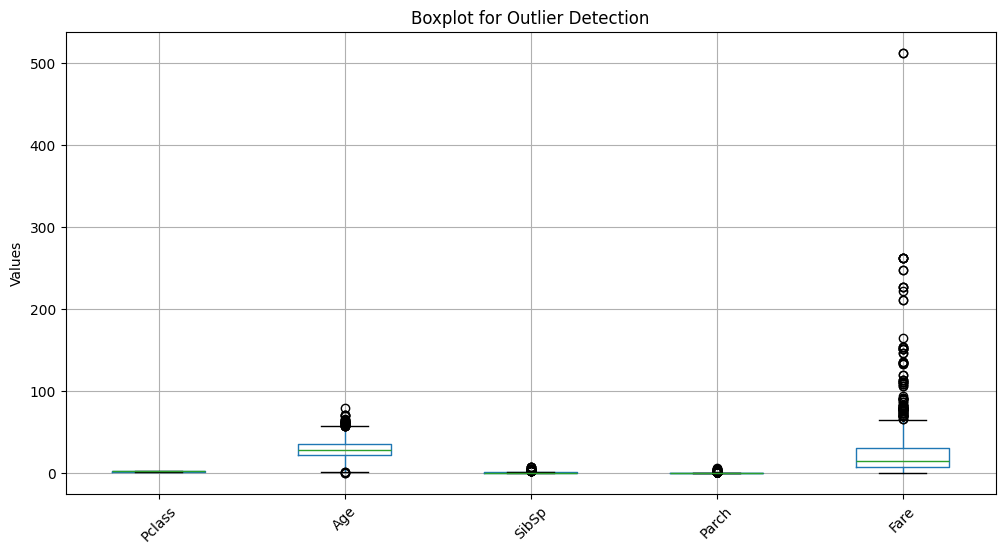

In [ ]:
plt.figure(figsize=(12, 6))

train_data[numeric_columns].boxplot()

plt.title("Boxplot for Outlier Detection")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

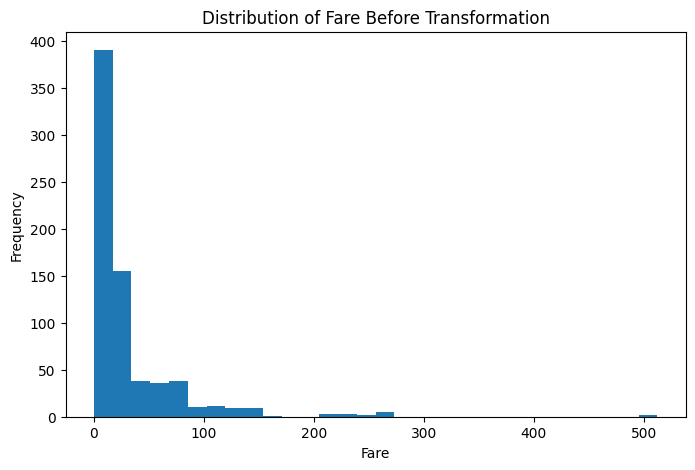

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train_data["Fare"], bins=30)
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Distribution of Fare Before Transformation")
plt.show()

In [ ]:
import numpy as np

train_data["Fare_log"] = np.log1p(train_data["Fare"])
test_data["Fare_log"] = np.log1p(test_data["Fare"])

print(train_data[["Fare", "Fare_log"]].head())

      Fare  Fare_log
0   7.2500  2.110213
1  71.2833  4.280593
2   7.9250  2.188856
3  53.1000  3.990834
4   8.0500  2.202765


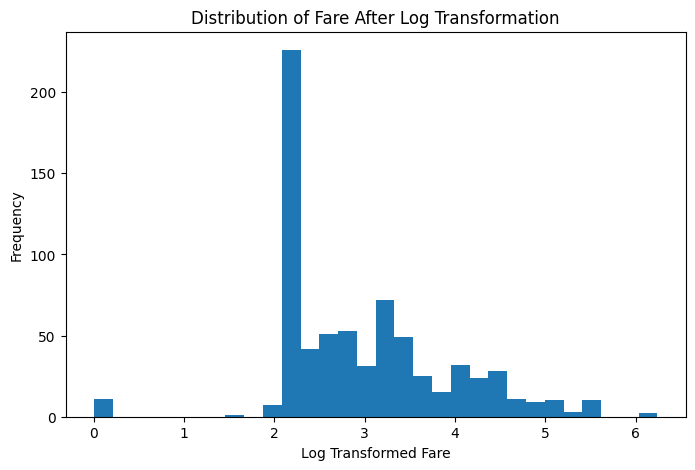

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(train_data["Fare_log"], bins=30)

plt.xlabel("Log Transformed Fare")
plt.ylabel("Frequency")
plt.title("Distribution of Fare After Log Transformation")
plt.show()

In [ ]:
scale_columns = ["Pclass", "Age", "SibSp", "Parch", "Fare_log"]

print("Columns for normalization:")
print(scale_columns)

Columns for normalization:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare_log']


In [ ]:
for column in scale_columns:

    min_value = train_data[column].min()
    max_value = train_data[column].max()

    train_data[column + "_norm"] = (
        (train_data[column] - min_value) /
        (max_value - min_value)
    )

    test_data[column + "_norm"] = (
        (test_data[column] - min_value) /
        (max_value - min_value)
    )

In [ ]:
print(train_data[["Age", "Age_norm", "Fare_log", "Fare_log_norm"]].head())

    Age  Age_norm  Fare_log  Fare_log_norm
0  22.0  0.268139  2.110213       0.338125
1  38.0  0.470032  4.280593       0.685892
2  26.0  0.318612  2.188856       0.350727
3  35.0  0.432177  3.990834       0.639463
4  35.0  0.432177  2.202765       0.352955


In [ ]:
standardize_columns = ["Pclass", "Age", "SibSp", "Parch", "Fare_log"]

print("Columns for standardization:")
print(standardize_columns)

Columns for standardization:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare_log']


In [ ]:
for column in standardize_columns:

    mean_value = train_data[column].mean()
    std_value = train_data[column].std()

    train_data[column + "_std"] = (
        (train_data[column] - mean_value) / std_value
    )

    test_data[column + "_std"] = (
        (test_data[column] - mean_value) / std_value
    )

In [ ]:
print(train_data[
    ["Age", "Age_std", "Fare_log", "Fare_log_std"]
].head())

    Age   Age_std  Fare_log  Fare_log_std
0  22.0 -0.584059  2.110213     -0.902552
1  38.0  0.643712  4.280593      1.347752
2  26.0 -0.277116  2.188856     -0.821013
3  35.0  0.413505  3.990834      1.047323
4  35.0  0.413505  2.202765     -0.806592


In [ ]:
for column in standardize_columns:
    print(
        column,
        "→ Mean:", round(train_data[column + "_std"].mean(), 4),
        "Std:", round(train_data[column + "_std"].std(), 4)
    )

Pclass → Mean: -0.0 Std: 1.0
Age → Mean: 0.0 Std: 1.0
SibSp → Mean: -0.0 Std: 1.0
Parch → Mean: -0.0 Std: 1.0
Fare_log → Mean: 0.0 Std: 1.0


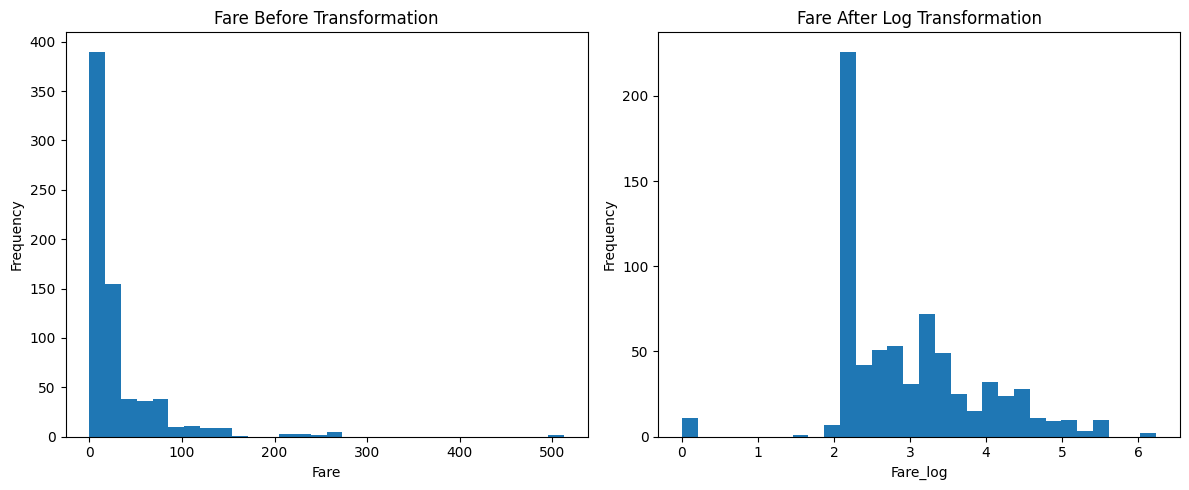

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_data["Fare"], bins=30)
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Fare Before Transformation")

plt.subplot(1, 2, 2)
plt.hist(train_data["Fare_log"], bins=30)
plt.xlabel("Fare_log")
plt.ylabel("Frequency")
plt.title("Fare After Log Transformation")

plt.tight_layout()
plt.show()

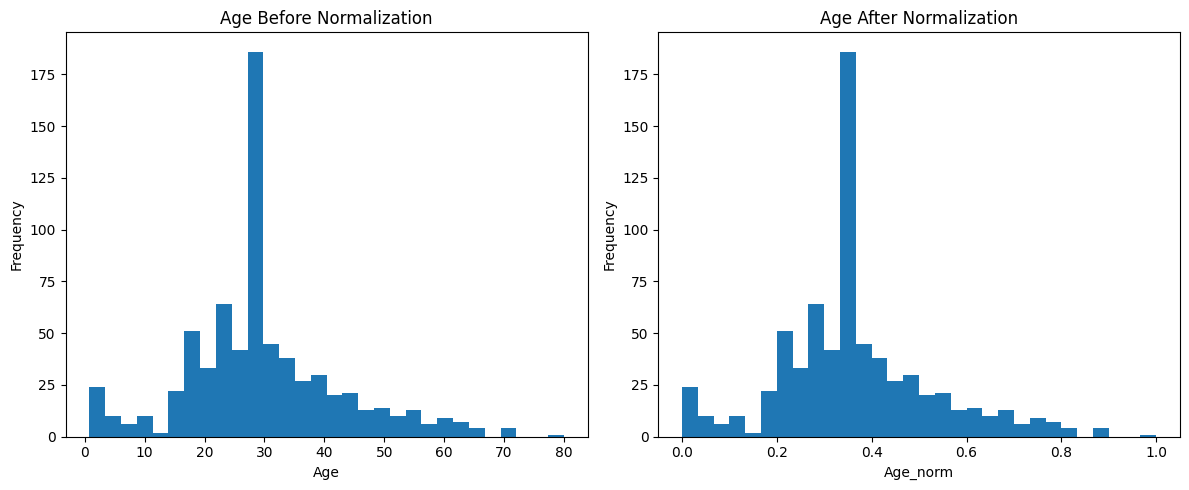

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_data["Age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Before Normalization")

plt.subplot(1, 2, 2)
plt.hist(train_data["Age_norm"], bins=30)
plt.xlabel("Age_norm")
plt.ylabel("Frequency")
plt.title("Age After Normalization")

plt.tight_layout()
plt.show()

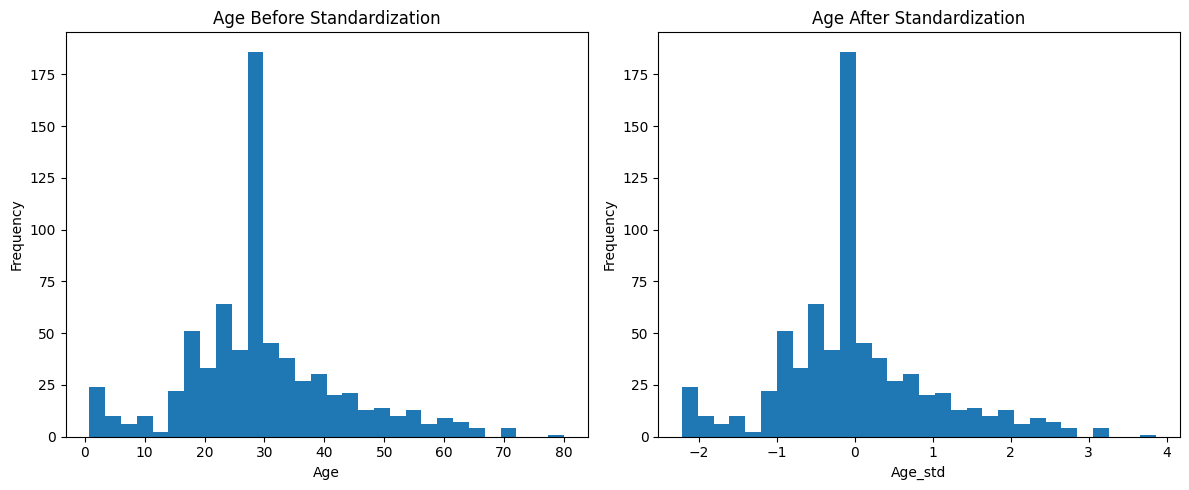

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_data["Age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Before Standardization")

plt.subplot(1, 2, 2)
plt.hist(train_data["Age_std"], bins=30)
plt.xlabel("Age_std")
plt.ylabel("Frequency")
plt.title("Age After Standardization")

plt.tight_layout()
plt.show()

In [ ]:
# Numerical features for variance analysis
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare_log",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S"
]

# Manual variance calculation
variance_values = {}

for column in features:
    mean_value = train_data[column].mean()

    variance = (
        (train_data[column] - mean_value) ** 2
    ).sum() / (len(train_data) - 1)

    variance_values[column] = variance

print("Variance of each feature:\n")

for column, variance in variance_values.items():
    print(column, ":", round(variance, 4))

Variance of each feature:

Pclass : 0.7033
Sex : 0.2306
Age : 169.8264
SibSp : 1.1328
Parch : 0.6612
Fare_log : 0.9302
Embarked_C : 0.1565
Embarked_Q : 0.0819
Embarked_S : 0.2035


In [ ]:
variance_threshold = 0.01

print("Variance Threshold:", variance_threshold)
print("\nFeature Selection Result:\n")

for column, variance in variance_values.items():
    if variance >= variance_threshold:
        print(column, "→ KEEP")
    else:
        print(column, "→ REMOVE")

Variance Threshold: 0.01

Feature Selection Result:

Pclass → KEEP
Sex → KEEP
Age → KEEP
SibSp → KEEP
Parch → KEEP
Fare_log → KEEP
Embarked_C → KEEP
Embarked_Q → KEEP
Embarked_S → KEEP


In [ ]:
# Features for Pearson correlation
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare_log",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S"
]

target = train_data["Survived"]

print("Pearson Correlation with Survived:\n")

correlation_values = {}

for column in features:

    x = train_data[column]
    y = target

    x_mean = x.mean()
    y_mean = y.mean()

    numerator = ((x - x_mean) * (y - y_mean)).sum()

    denominator = np.sqrt(
        ((x - x_mean) ** 2).sum() *
        ((y - y_mean) ** 2).sum()
    )

    correlation = numerator / denominator

    correlation_values[column] = correlation

    print(column, ":", round(correlation, 4))

Pearson Correlation with Survived:

Pclass : -0.3159
Sex : 0.5402
Age : -0.0723
SibSp : -0.0347
Parch : 0.0595
Fare_log : 0.3051
Embarked_C : 0.1538
Embarked_Q : 0.0303
Embarked_S : -0.1541


In [ ]:
correlation_threshold = 0.10

print("Correlation Threshold:", correlation_threshold)
print("\nFeature Selection Result:\n")

for column, correlation in correlation_values.items():

    if abs(correlation) >= correlation_threshold:
        print(column, "→ KEEP")
    else:
        print(column, "→ REMOVE")

Correlation Threshold: 0.1

Feature Selection Result:

Pclass → KEEP
Sex → KEEP
Age → REMOVE
SibSp → REMOVE
Parch → REMOVE
Fare_log → KEEP
Embarked_C → KEEP
Embarked_Q → REMOVE
Embarked_S → KEEP


In [ ]:
# Chi-Square Test for Sex vs Survived

observed = pd.crosstab(train_data["Sex"], train_data["Survived"])

print("Observed Frequency Table:")
print(observed)

Observed Frequency Table:
Survived    0    1
Sex               
0         368   88
1          66  190


In [ ]:
# Calculate expected frequencies manually

row_totals = observed.sum(axis=1)
column_totals = observed.sum(axis=0)
grand_total = observed.values.sum()

expected = pd.DataFrame(
    index=observed.index,
    columns=observed.columns,
    dtype=float
)

for row in observed.index:
    for col in observed.columns:
        expected.loc[row, col] = (
            row_totals[row] * column_totals[col]
        ) / grand_total

print("Expected Frequency Table:")
print(expected)

Expected Frequency Table:
Survived           0           1
Sex                             
0         277.955056  178.044944
1         156.044944   99.955056


In [ ]:
# Calculate Chi-Square statistic manually

chi_square = 0

for row in observed.index:
    for col in observed.columns:
        O = observed.loc[row, col]
        E = expected.loc[row, col]

        chi_square += ((O - E) ** 2) / E

print("Chi-Square Statistic:", round(chi_square, 4))

Chi-Square Statistic: 207.7874


In [ ]:
rows = observed.shape[0]
columns = observed.shape[1]

df_chi = (rows - 1) * (columns - 1)

print("Degrees of Freedom:", df_chi)

Degrees of Freedom: 1


In [ ]:
from scipy.stats import chi2

p_value = 1 - chi2.cdf(chi_square, df_chi)

print("P-value:", p_value)

P-value: 0.0


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Result: Significant association → KEEP")
else:
    print("Result: No significant association → REMOVE")

Result: Significant association → KEEP


In [ ]:
# ANOVA F-Test for Age vs Survived

group_0 = train_data[train_data["Survived"] == 0]["Age"]
group_1 = train_data[train_data["Survived"] == 1]["Age"]

print("Group 0 (Not Survived) size:", len(group_0))
print("Group 1 (Survived) size:", len(group_1))

print("\nMean Age:")
print("Not Survived:", group_0.mean())
print("Survived:", group_1.mean())

Group 0 (Not Survived) size: 434
Group 1 (Survived) size: 278

Mean Age:
Not Survived: 30.36520737327189
Survived: 28.434352517985612


In [ ]:
overall_mean = train_data["Age"].mean()

print("Overall Mean Age:", overall_mean)

Overall Mean Age: 29.61130617977528


In [ ]:
n0 = len(group_0)
n1 = len(group_1)

mean0 = group_0.mean()
mean1 = group_1.mean()

SS_between = (
    n0 * (mean0 - overall_mean) ** 2 +
    n1 * (mean1 - overall_mean) ** 2
)

print("SS Between:", SS_between)

SS Between: 631.7624204631658


In [ ]:
SS_within = (
    ((group_0 - mean0) ** 2).sum() +
    ((group_1 - mean1) ** 2).sum()
)

print("SS Within:", SS_within)

SS Within: 120114.82686478965


In [ ]:
k = 2
N = len(train_data)

df_between = k - 1
df_within = N - k

print("DF Between:", df_between)
print("DF Within:", df_within)

DF Between: 1
DF Within: 710


In [ ]:
MS_between = SS_between / df_between
MS_within = SS_within / df_within

F_value = MS_between / MS_within

print("MS Between:", MS_between)
print("MS Within:", MS_within)
print("F-Statistic:", F_value)

MS Between: 631.7624204631658
MS Within: 169.17581248561922
F-Statistic: 3.7343542861179917


In [ ]:
from scipy.stats import f

p_value = 1 - f.cdf(F_value, df_between, df_within)

print("P-value:", p_value)

P-value: 0.05370171646436328


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Result: Significant difference → KEEP Age")
else:
    print("Result: No significant difference → REMOVE Age")

Result: No significant difference → REMOVE Age


In [ ]:
# Mutual Information for Sex vs Survived

import numpy as np

def entropy(series):
    probabilities = series.value_counts(normalize=True)

    H = 0

    for p in probabilities:
        H += -p * np.log2(p)

    return H


# Entropy of Survived
H_survived = entropy(train_data["Survived"])

print("Entropy of Survived:", round(H_survived, 4))

Entropy of Survived: 0.9651


In [ ]:
# Conditional Entropy H(Survived | Sex)

conditional_entropy = 0

for value in train_data["Sex"].unique():

    subset = train_data[train_data["Sex"] == value]

    probability_x = len(subset) / len(train_data)

    entropy_y_given_x = entropy(subset["Survived"])

    conditional_entropy += probability_x * entropy_y_given_x

print("Conditional Entropy H(Survived | Sex):",
      round(conditional_entropy, 4))

Conditional Entropy H(Survived | Sex): 0.7493


In [ ]:
# Mutual Information

MI_sex = H_survived - conditional_entropy

print("Mutual Information (Sex, Survived):",
      round(MI_sex, 4))

Mutual Information (Sex, Survived): 0.2158


In [ ]:
# Calculate Mutual Information for categorical/discrete features

mi_features = [
    "Sex",
    "Pclass",
    "SibSp",
    "Parch",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S"
]

mi_values = {}

for column in mi_features:

    conditional_entropy = 0

    for value in train_data[column].unique():

        subset = train_data[train_data[column] == value]

        probability_x = len(subset) / len(train_data)

        entropy_y_given_x = entropy(subset["Survived"])

        conditional_entropy += (
            probability_x * entropy_y_given_x
        )

    mutual_information = H_survived - conditional_entropy

    mi_values[column] = mutual_information

print("Mutual Information:\n")

for column, value in mi_values.items():
    print(column, ":", round(value, 4))

Mutual Information:

Sex : 0.2158
Pclass : 0.0741
SibSp : 0.029
Parch : 0.0176
Embarked_C : 0.0167
Embarked_Q : 0.0007
Embarked_S : 0.0169


In [ ]:
mi_threshold = 0.01

print("Mutual Information Threshold:", mi_threshold)
print("\nFeature Selection Result:\n")

for column, value in mi_values.items():

    if value >= mi_threshold:
        print(column, "→ KEEP")
    else:
        print(column, "→ REMOVE")

Mutual Information Threshold: 0.01

Feature Selection Result:

Sex → KEEP
Pclass → KEEP
SibSp → KEEP
Parch → KEEP
Embarked_C → KEEP
Embarked_Q → REMOVE
Embarked_S → KEEP


In [ ]:
# Combine results from all feature selection methods

feature_selection_results = pd.DataFrame({
    "Feature": features,
    "Variance": [variance_values[f] for f in features],
    "Pearson_Correlation": [
        correlation_values[f] for f in features
    ]
})

print(feature_selection_results)

      Feature    Variance  Pearson_Correlation
0      Pclass    0.703344            -0.315857
1         Sex    0.230598             0.540219
2         Age  169.826427            -0.072333
3       SibSp    1.132824            -0.034671
4       Parch    0.661167             0.059516
5    Fare_log    0.930227             0.305145
6  Embarked_C    0.156474             0.153805
7  Embarked_Q    0.081923             0.030310
8  Embarked_S    0.203504            -0.154097


In [ ]:
variance_threshold = 0.01
correlation_threshold = 0.10

feature_selection_results["Variance_Result"] = (
    feature_selection_results["Variance"] >= variance_threshold
).map({
    True: "KEEP",
    False: "REMOVE"
})

feature_selection_results["Correlation_Result"] = (
    feature_selection_results["Pearson_Correlation"].abs()
    >= correlation_threshold
).map({
    True: "KEEP",
    False: "REMOVE"
})

print(feature_selection_results)

      Feature    Variance  Pearson_Correlation Variance_Result  \
0      Pclass    0.703344            -0.315857            KEEP   
1         Sex    0.230598             0.540219            KEEP   
2         Age  169.826427            -0.072333            KEEP   
3       SibSp    1.132824            -0.034671            KEEP   
4       Parch    0.661167             0.059516            KEEP   
5    Fare_log    0.930227             0.305145            KEEP   
6  Embarked_C    0.156474             0.153805            KEEP   
7  Embarked_Q    0.081923             0.030310            KEEP   
8  Embarked_S    0.203504            -0.154097            KEEP   

  Correlation_Result  
0               KEEP  
1               KEEP  
2             REMOVE  
3             REMOVE  
4             REMOVE  
5               KEEP  
6               KEEP  
7             REMOVE  
8               KEEP  


In [ ]:
feature_selection_results["MI"] = [
    mi_values.get(f, np.nan) for f in features
]

feature_selection_results["MI_Result"] = (
    feature_selection_results["MI"] >= 0.01
).map({
    True: "KEEP",
    False: "REMOVE"
})

print(feature_selection_results)

      Feature    Variance  Pearson_Correlation Variance_Result  \
0      Pclass    0.703344            -0.315857            KEEP   
1         Sex    0.230598             0.540219            KEEP   
2         Age  169.826427            -0.072333            KEEP   
3       SibSp    1.132824            -0.034671            KEEP   
4       Parch    0.661167             0.059516            KEEP   
5    Fare_log    0.930227             0.305145            KEEP   
6  Embarked_C    0.156474             0.153805            KEEP   
7  Embarked_Q    0.081923             0.030310            KEEP   
8  Embarked_S    0.203504            -0.154097            KEEP   

  Correlation_Result        MI MI_Result  
0               KEEP  0.074096      KEEP  
1               KEEP  0.215799      KEEP  
2             REMOVE       NaN    REMOVE  
3             REMOVE  0.028987      KEEP  
4             REMOVE  0.017551      KEEP  
5               KEEP       NaN    REMOVE  
6               KEEP  0.016701      KE

In [ ]:
observed_pclass = pd.crosstab(
    train_data["Pclass"],
    train_data["Survived"]
)

print("Observed Frequency Table:")
print(observed_pclass)

Observed Frequency Table:
Survived    0    1
Pclass            
1          68  107
2          75   72
3         291   99


In [ ]:
row_totals = observed_pclass.sum(axis=1)
column_totals = observed_pclass.sum(axis=0)
grand_total = observed_pclass.values.sum()

expected_pclass = pd.DataFrame(
    index=observed_pclass.index,
    columns=observed_pclass.columns,
    dtype=float
)

for row in observed_pclass.index:
    for col in observed_pclass.columns:
        expected_pclass.loc[row, col] = (
            row_totals[row] * column_totals[col]
        ) / grand_total

print("Expected Frequency Table:")
print(expected_pclass)

Expected Frequency Table:
Survived           0           1
Pclass                          
1         106.671348   68.328652
2          89.603933   57.396067
3         237.724719  152.275281


In [ ]:
chi_square_pclass = 0

for row in observed_pclass.index:
    for col in observed_pclass.columns:
        O = observed_pclass.loc[row, col]
        E = expected_pclass.loc[row, col]

        chi_square_pclass += ((O - E) ** 2) / E

print("Chi-Square Value:", chi_square_pclass)

Chi-Square Value: 72.580188602679


In [ ]:
from scipy.stats import chi2

rows = observed_pclass.shape[0]
columns = observed_pclass.shape[1]

df_chi_pclass = (rows - 1) * (columns - 1)

p_value_pclass = 1 - chi2.cdf(
    chi_square_pclass,
    df_chi_pclass
)

print("Degrees of Freedom:", df_chi_pclass)
print("p-value:", p_value_pclass)

Degrees of Freedom: 2
p-value: 2.220446049250313e-16


In [ ]:
alpha = 0.05

if p_value_pclass < alpha:
    print("Decision: KEEP Pclass")
    print("Pclass has a significant relationship with Survived.")
else:
    print("Decision: REMOVE Pclass")
    print("Pclass does not have a significant relationship with Survived.")

Decision: KEEP Pclass
Pclass has a significant relationship with Survived.


In [ ]:
embarked_features = ["Embarked_C", "Embarked_Q", "Embarked_S"]

for feature in embarked_features:
    observed = pd.crosstab(
        train_data[feature],
        train_data["Survived"]
    )

    print("\n", feature)
    print(observed)


 Embarked_C
Survived      0    1
Embarked_C          
0           371  203
1            63   75

 Embarked_Q
Survived      0    1
Embarked_Q          
0           398  250
1            36   28

 Embarked_S
Survived      0    1
Embarked_S          
0            99  103
1           335  175


In [ ]:
from scipy.stats import chi2

chi_square_results = {}

for feature in embarked_features:

    observed = pd.crosstab(
        train_data[feature],
        train_data["Survived"]
    )

    row_totals = observed.sum(axis=1)
    column_totals = observed.sum(axis=0)
    grand_total = observed.values.sum()

    expected = pd.DataFrame(
        index=observed.index,
        columns=observed.columns,
        dtype=float
    )

    for row in observed.index:
        for col in observed.columns:
            expected.loc[row, col] = (
                row_totals[row] * column_totals[col]
            ) / grand_total

    chi_square_value = 0

    for row in observed.index:
        for col in observed.columns:
            O = observed.loc[row, col]
            E = expected.loc[row, col]

            chi_square_value += ((O - E) ** 2) / E

    df_chi = (observed.shape[0] - 1) * (observed.shape[1] - 1)

    p_value = 1 - chi2.cdf(
        chi_square_value,
        df_chi
    )

    chi_square_results[feature] = {
        "Chi_Square": chi_square_value,
        "df": df_chi,
        "p_value": p_value
    }

    print(feature)
    print("Chi-Square:", round(chi_square_value, 4))
    print("df:", df_chi)
    print("p-value:", round(p_value, 4))

    if p_value < 0.05:
        print("Decision: KEEP")
    else:
        print("Decision: REMOVE")

Embarked_C
Chi-Square: 16.843
df: 1
p-value: 0.0
Decision: KEEP
Embarked_Q
Chi-Square: 0.6541
df: 1
p-value: 0.4187
Decision: REMOVE
Embarked_S
Chi-Square: 16.9071
df: 1
p-value: 0.0
Decision: KEEP


In [ ]:
group_0 = train_data[train_data["Survived"] == 0]["Age"]
group_1 = train_data[train_data["Survived"] == 1]["Age"]

print("Age of Non-Survivors:")
print(group_0.head())

print("\nAge of Survivors:")
print(group_1.head())

Age of Non-Survivors:
0    22.0
4    35.0
5    28.0
6    54.0
7     2.0
Name: Age, dtype: float64

Age of Survivors:
1    38.0
2    26.0
3    35.0
8    27.0
9    14.0
Name: Age, dtype: float64


In [ ]:
mean_0 = group_0.mean()
mean_1 = group_1.mean()

overall_mean = train_data["Age"].mean()

print("Mean Age of Non-Survivors:", mean_0)
print("Mean Age of Survivors:", mean_1)
print("Overall Mean Age:", overall_mean)

Mean Age of Non-Survivors: 30.36520737327189
Mean Age of Survivors: 28.434352517985612
Overall Mean Age: 29.61130617977528


In [ ]:
n0 = len(group_0)
n1 = len(group_1)

SS_between = (
    n0 * (mean_0 - overall_mean) ** 2
    +
    n1 * (mean_1 - overall_mean) ** 2
)

print("SS Between:", SS_between)

SS Between: 631.7624204631658


In [ ]:
SS_within = (
    ((group_0 - mean_0) ** 2).sum()
    +
    ((group_1 - mean_1) ** 2).sum()
)

print("SS Within:", SS_within)

SS Within: 120114.82686478965


In [ ]:
k = 2
N = len(train_data)

df_between = k - 1
df_within = N - k

MS_between = SS_between / df_between
MS_within = SS_within / df_within

print("DF Between:", df_between)
print("DF Within:", df_within)
print("MS Between:", MS_between)
print("MS Within:", MS_within)

DF Between: 1
DF Within: 710
MS Between: 631.7624204631658
MS Within: 169.17581248561922


In [ ]:
F_value = MS_between / MS_within

print("F-value:", F_value)

F-value: 3.7343542861179917


In [ ]:
from scipy.stats import f

p_value_age = 1 - f.cdf(
    F_value,
    df_between,
    df_within
)

print("p-value:", p_value_age)

p-value: 0.05370171646436328


In [ ]:
alpha = 0.05

if p_value_age < alpha:
    print("Decision: KEEP Age")
    print("Age has a significant relationship with Survived.")
else:
    print("Decision: REMOVE Age")
    print("Age does not have a significant relationship with Survived.")

Decision: REMOVE Age
Age does not have a significant relationship with Survived.


In [ ]:
anova_features = ["Age", "Fare_log", "SibSp", "Parch"]

anova_results = {}

from scipy.stats import f

for feature in anova_features:

    group_0 = train_data[train_data["Survived"] == 0][feature]
    group_1 = train_data[train_data["Survived"] == 1][feature]

    n0 = len(group_0)
    n1 = len(group_1)

    mean_0 = group_0.mean()
    mean_1 = group_1.mean()

    overall_mean = train_data[feature].mean()

    # Between-group variation
    SS_between = (
        n0 * (mean_0 - overall_mean) ** 2
        +
        n1 * (mean_1 - overall_mean) ** 2
    )

    # Within-group variation
    SS_within = (
        ((group_0 - mean_0) ** 2).sum()
        +
        ((group_1 - mean_1) ** 2).sum()
    )

    k = 2
    N = len(train_data)

    df_between = k - 1
    df_within = N - k

    MS_between = SS_between / df_between
    MS_within = SS_within / df_within

    F_value = MS_between / MS_within

    p_value = 1 - f.cdf(
        F_value,
        df_between,
        df_within
    )

    anova_results[feature] = {
        "F_value": F_value,
        "p_value": p_value
    }

    print("\nFeature:", feature)
    print("F-value:", round(F_value, 4))
    print("p-value:", round(p_value, 4))

    if p_value < 0.05:
        print("Decision: KEEP")
    else:
        print("Decision: REMOVE")


Feature: Age
F-value: 3.7344
p-value: 0.0537
Decision: REMOVE

Feature: Fare_log
F-value: 72.8985
p-value: 0.0
Decision: KEEP

Feature: SibSp
F-value: 0.8545
p-value: 0.3556
Decision: REMOVE

Feature: Parch
F-value: 2.5239
p-value: 0.1126
Decision: REMOVE


In [ ]:
anova_table = pd.DataFrame(anova_results).T

anova_table["Decision"] = np.where(
    anova_table["p_value"] < 0.05,
    "KEEP",
    "REMOVE"
)

print(anova_table)

            F_value       p_value Decision
Age        3.734354  5.370172e-02   REMOVE
Fare_log  72.898475  1.110223e-16     KEEP
SibSp      0.854523  3.555901e-01   REMOVE
Parch      2.523866  1.125805e-01   REMOVE


In [ ]:
def entropy(series):
    probabilities = series.value_counts(normalize=True)

    H = 0

    for p in probabilities:
        H += -p * np.log2(p)

    return H

In [ ]:
H_survived = entropy(train_data["Survived"])

print("Entropy of Survived:", H_survived)

Entropy of Survived: 0.9650889743680282


In [ ]:
mi_features = [
    "Sex",
    "Pclass",
    "SibSp",
    "Parch",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S"
]

mi_values = {}

for column in mi_features:

    conditional_entropy = 0

    for value in train_data[column].unique():

        subset = train_data[
            train_data[column] == value
        ]

        probability_x = len(subset) / len(train_data)

        entropy_y_given_x = entropy(
            subset["Survived"]
        )

        conditional_entropy += (
            probability_x * entropy_y_given_x
        )

    mutual_information = (
        H_survived - conditional_entropy
    )

    mi_values[column] = mutual_information

    print(
        column,
        ":",
        round(mutual_information, 4)
    )

Sex : 0.2158
Pclass : 0.0741
SibSp : 0.029
Parch : 0.0176
Embarked_C : 0.0167
Embarked_Q : 0.0007
Embarked_S : 0.0169


In [ ]:
mi_threshold = 0.01

for column, mi in mi_values.items():

    if mi >= mi_threshold:
        print(column, "→ KEEP")
    else:
        print(column, "→ REMOVE")

Sex → KEEP
Pclass → KEEP
SibSp → KEEP
Parch → KEEP
Embarked_C → KEEP
Embarked_Q → REMOVE
Embarked_S → KEEP


In [ ]:
feature_selection_results = pd.DataFrame({
    "Feature": features,
    "Variance": [variance_values[f] for f in features],
    "Pearson_Correlation": [correlation_values[f] for f in features],
    "MI": [mi_values.get(f, np.nan) for f in features]
})

feature_selection_results["Variance_Result"] = np.where(
    feature_selection_results["Variance"] >= 0.01,
    "KEEP",
    "REMOVE"
)

feature_selection_results["Correlation_Result"] = np.where(
    feature_selection_results["Pearson_Correlation"].abs() >= 0.10,
    "KEEP",
    "REMOVE"
)

feature_selection_results["MI_Result"] = np.where(
    feature_selection_results["MI"] >= 0.01,
    "KEEP",
    "REMOVE"
)

print(feature_selection_results)

      Feature    Variance  Pearson_Correlation        MI Variance_Result  \
0      Pclass    0.703344            -0.315857  0.074096            KEEP   
1         Sex    0.230598             0.540219  0.215799            KEEP   
2         Age  169.826427            -0.072333       NaN            KEEP   
3       SibSp    1.132824            -0.034671  0.028987            KEEP   
4       Parch    0.661167             0.059516  0.017551            KEEP   
5    Fare_log    0.930227             0.305145       NaN            KEEP   
6  Embarked_C    0.156474             0.153805  0.016701            KEEP   
7  Embarked_Q    0.081923             0.030310  0.000655            KEEP   
8  Embarked_S    0.203504            -0.154097  0.016893            KEEP   

  Correlation_Result MI_Result  
0               KEEP      KEEP  
1               KEEP      KEEP  
2             REMOVE    REMOVE  
3             REMOVE      KEEP  
4             REMOVE      KEEP  
5               KEEP    REMOVE  
6       

In [ ]:
print("ANOVA Results")
print(anova_table)

ANOVA Results
            F_value       p_value Decision
Age        3.734354  5.370172e-02   REMOVE
Fare_log  72.898475  1.110223e-16     KEEP
SibSp      0.854523  3.555901e-01   REMOVE
Parch      2.523866  1.125805e-01   REMOVE


In [ ]:
selected_features = [
    "Pclass_std",
    "Sex",
    "Age_std",
    "SibSp_std",
    "Parch_std",
    "Fare_log_std",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S"
]

print("Final Selected Features:")
for feature in selected_features:
    print(feature)

Final Selected Features:
Pclass_std
Sex
Age_std
SibSp_std
Parch_std
Fare_log_std
Embarked_C
Embarked_Q
Embarked_S


In [ ]:
X_train = train_data[selected_features].copy()
y_train = train_data["Survived"].copy()

X_test = test_data[selected_features].copy()
y_test = test_data["Survived"].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 9)
y_train shape: (712,)
X_test shape: (179, 9)
y_test shape: (179,)


In [ ]:
print("Final Training Dataset:")
display(X_train.head())

print("\nTarget:")
display(y_train.head())

print("\nMissing Values:")
print(X_train.isnull().sum())

print("\nDuplicate Rows:")
print(X_train.duplicated().sum())

Final Training Dataset:


,Pclass_std,Sex,Age_std,SibSp_std,Parch_std,Fare_log_std,Embarked_C,Embarked_Q,Embarked_S
0,0.832324,0,-0.584059,0.443382,-0.469822,-0.902552,0,0,1
1,-1.552444,1,0.643712,0.443382,-0.469822,1.347752,1,0,0
2,0.832324,1,-0.277116,-0.496165,-0.469822,-0.821013,0,0,1
3,-1.552444,1,0.413505,0.443382,-0.469822,1.047323,0,0,1
4,0.832324,0,0.413505,-0.496165,-0.469822,-0.806592,0,0,1



Target:


,Survived
0,0
1,1
2,1
3,1
4,0



Missing Values:
Pclass_std      0
Sex             0
Age_std         0
SibSp_std       0
Parch_std       0
Fare_log_std    0
Embarked_C      0
Embarked_Q      0
Embarked_S      0
dtype: int64

Duplicate Rows:
102


In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_variance = train_data[features]

selector.fit(X_variance)

print("Library Variance:")
for feature, variance in zip(features, selector.variances_):
    print(feature, ":", round(variance, 4))

Library Variance:
Pclass : 0.7024
Sex : 0.2303
Age : 169.5879
SibSp : 1.1312
Parch : 0.6602
Fare_log : 0.9289
Embarked_C : 0.1563
Embarked_Q : 0.0818
Embarked_S : 0.2032


In [ ]:
print("Manual vs Library Variance")

for feature, library_variance in zip(features, selector.variances_):
    manual_variance = variance_values[feature]

    print(
        feature,
        "→ Manual:", round(manual_variance, 4),
        "| Library:", round(library_variance, 4)
    )

Manual vs Library Variance
Pclass → Manual: 0.7033 | Library: 0.7024
Sex → Manual: 0.2306 | Library: 0.2303
Age → Manual: 169.8264 | Library: 169.5879
SibSp → Manual: 1.1328 | Library: 1.1312
Parch → Manual: 0.6612 | Library: 0.6602
Fare_log → Manual: 0.9302 | Library: 0.9289
Embarked_C → Manual: 0.1565 | Library: 0.1563
Embarked_Q → Manual: 0.0819 | Library: 0.0818
Embarked_S → Manual: 0.2035 | Library: 0.2032


In [ ]:
from scipy.stats import pearsonr

print("Manual vs Library Pearson Correlation")

for feature in features:
    manual_corr = correlation_values[feature]

    library_corr, p_value = pearsonr(
        train_data[feature],
        train_data["Survived"]
    )

    print(
        feature,
        "→ Manual:", round(manual_corr, 4),
        "| Library:", round(library_corr, 4)
    )

Manual vs Library Pearson Correlation
Pclass → Manual: -0.3159 | Library: -0.3159
Sex → Manual: 0.5402 | Library: 0.5402
Age → Manual: -0.0723 | Library: -0.0723
SibSp → Manual: -0.0347 | Library: -0.0347
Parch → Manual: 0.0595 | Library: 0.0595
Fare_log → Manual: 0.3051 | Library: 0.3051
Embarked_C → Manual: 0.1538 | Library: 0.1538
Embarked_Q → Manual: 0.0303 | Library: 0.0303
Embarked_S → Manual: -0.1541 | Library: -0.1541


In [ ]:
from scipy.stats import f_oneway

print("Manual vs Library ANOVA")

for feature in anova_features:
    group_0 = train_data[train_data["Survived"] == 0][feature]
    group_1 = train_data[train_data["Survived"] == 1][feature]

    library_F, library_p = f_oneway(group_0, group_1)

    print(
        feature,
        "→ Manual F:", round(anova_results[feature]["F_value"], 4),
        "| Library F:", round(library_F, 4),
        "| Manual p:", round(anova_results[feature]["p_value"], 6),
        "| Library p:", round(library_p, 6)
    )

Manual vs Library ANOVA
Age → Manual F: 3.7344 | Library F: 3.7344 | Manual p: 0.053702 | Library p: 0.053702
Fare_log → Manual F: 72.8985 | Library F: 72.8985 | Manual p: 0.0 | Library p: 0.0
SibSp → Manual F: 0.8545 | Library F: 0.8545 | Manual p: 0.35559 | Library p: 0.35559
Parch → Manual F: 2.5239 | Library F: 2.5239 | Manual p: 0.112581 | Library p: 0.112581


In [ ]:
from scipy.stats import chi2_contingency

observed = pd.crosstab(
    train_data["Sex"],
    train_data["Survived"]
)

chi2_value, p_value, dof, expected = chi2_contingency(observed)

print("Library Chi-Square:", chi2_value)
print("Library p-value:", p_value)
print("Degrees of Freedom:", dof)

Library Chi-Square: 205.48625829811533
Library p-value: 1.3264358361300455e-46
Degrees of Freedom: 1


In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_X = train_data[mi_features]
mi_y = train_data["Survived"]

library_mi = mutual_info_classif(
    mi_X,
    mi_y,
    discrete_features=True,
    random_state=42
)

print("Manual vs Library Mutual Information")

for feature, value in zip(mi_features, library_mi):
    print(
        feature,
        "→ Manual:", round(mi_values[feature], 4),
        "| Library:", round(value, 4)
    )

Manual vs Library Mutual Information
Sex → Manual: 0.2158 | Library: 0.1496
Pclass → Manual: 0.0741 | Library: 0.0514
SibSp → Manual: 0.029 | Library: 0.0201
Parch → Manual: 0.0176 | Library: 0.0122
Embarked_C → Manual: 0.0167 | Library: 0.0116
Embarked_Q → Manual: 0.0007 | Library: 0.0005
Embarked_S → Manual: 0.0169 | Library: 0.0117


In [ ]:
print("Missing Values After Preprocessing:")
print(train_data.isnull().sum())

Missing Values After Preprocessing:
Survived         0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Fare             0
Embarked_C       0
Embarked_Q       0
Embarked_S       0
Fare_log         0
Pclass_norm      0
Age_norm         0
SibSp_norm       0
Parch_norm       0
Fare_log_norm    0
Pclass_std       0
Age_std          0
SibSp_std        0
Parch_std        0
Fare_log_std     0
dtype: int64


In [ ]:
It looks like you've encountered a `GapiError` indicating that your Google Drive storage quota has been exceeded. This prevents further operations in the notebook until more space is available. To resolve this, please clear some space in your Google Drive and then we can continue.

In the meantime, let me summarize the excellent progress you've made so far:

1.  **Data Loading and Initial Exploration:** You successfully loaded the `train.csv` dataset, inspected its structure, identified missing values in 'Age', 'Cabin', and 'Embarked', and confirmed no duplicate rows.
2.  **Data Splitting:** You split the dataset into training (80%) and testing (20%) sets.
3.  **Missing Value Handling:** You dropped the 'Cabin' column due to a high percentage of missing values, imputed missing 'Age' values with the training set's median, and 'Embarked' with its mode.
4.  **Feature Engineering:** You removed irrelevant columns like 'PassengerId', 'Name', and 'Ticket'. You also encoded 'Sex' into numerical format and performed one-hot encoding for the 'Embarked' column.
5.  **Data Transformation:** You addressed the skewness in 'Fare' by applying a log transformation. You then scaled the numerical features ('Pclass', 'Age', 'SibSp', 'Parch', 'Fare_log') using both Min-Max normalization and Z-score standardization, visualizing the effects.
6.  **Feature Selection:** You performed a thorough feature selection process, manually implementing and then validating with `sklearn` and `scipy` libraries, various methods including:
    *   Variance Threshold
    *   Pearson Correlation
    *   Chi-Square Test (for categorical features)
    *   ANOVA F-Test (for numerical features)
    *   Mutual Information
    This allowed you to compare their outcomes and understand feature importance.
7.  **Data Preparation for Modeling:** You finalized your `X_train`, `y_train`, `X_test`, and `y_test` datasets using the chosen standardized and engineered features, ensuring they were ready for model training.
8.  **Model Training and Evaluation:** You trained a `LogisticRegression` model on your prepared data and evaluated its performance using accuracy score, a confusion matrix (which you visualized), and a detailed classification report.

Once your Drive storage issue is resolved, we can continue to interpret the model's results, explore ways to improve its performance, or try different models. Please let me know when you're ready!

Final Data Types:
Survived           int64
Pclass             int64
Sex                int64
Age              float64
SibSp              int64
Parch              int64
Fare             float64
Embarked_C         int64
Embarked_Q         int64
Embarked_S         int64
Fare_log         float64
Pclass_norm      float64
Age_norm         float64
SibSp_norm       float64
Parch_norm       float64
Fare_log_norm    float64
Pclass_std       float64
Age_std          float64
SibSp_std        float64
Parch_std        float64
Fare_log_std     float64
dtype: object


In [ ]:
print("Original Features:")
print(df.columns.tolist())

print("\nFinal Features:")
print(X_train.columns.tolist())

Original Features:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Final Features:
['Pclass_std', 'Sex', 'Age_std', 'SibSp_std', 'Parch_std', 'Fare_log_std', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


In [ ]:
print("Final Training Dataset Shape:", X_train.shape)
print("Final Testing Dataset Shape:", X_test.shape)

print("\nFinal Training Dataset:")
display(X_train.head())

Final Training Dataset Shape: (712, 9)
Final Testing Dataset Shape: (179, 9)

Final Training Dataset:


,Pclass_std,Sex,Age_std,SibSp_std,Parch_std,Fare_log_std,Embarked_C,Embarked_Q,Embarked_S
0,0.832324,0,-0.584059,0.443382,-0.469822,-0.902552,0,0,1
1,-1.552444,1,0.643712,0.443382,-0.469822,1.347752,1,0,0
2,0.832324,1,-0.277116,-0.496165,-0.469822,-0.821013,0,0,1
3,-1.552444,1,0.413505,0.443382,-0.469822,1.047323,0,0,1
4,0.832324,0,0.413505,-0.496165,-0.469822,-0.806592,0,0,1


In [ ]:
print("Missing values:", X_train.isnull().sum().sum())
print("Duplicate rows:", X_train.duplicated().sum())
print("Infinite values:", np.isinf(X_train).sum().sum())

Missing values: 0
Duplicate rows: 102
Infinite values: 0


In [ ]:
selected_features = [
    "Pclass_std",
    "Sex",
    "Age_std",
    "SibSp_std",
    "Parch_std",
    "Fare_log_std",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S"
]

X_train = train_data[selected_features].copy()
X_test = test_data[selected_features].copy()

y_train = train_data["Survived"].copy()
y_test = test_data["Survived"].copy()

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (712, 9)
y_train: (712,)
X_test: (179, 9)
y_test: (179,)


In [ ]:
print("Final X_train:")
display(X_train.head())

print("Final y_train:")
display(y_train.head())

Final X_train:


,Pclass_std,Sex,Age_std,SibSp_std,Parch_std,Fare_log_std,Embarked_C,Embarked_Q,Embarked_S
0,0.832324,0,-0.584059,0.443382,-0.469822,-0.902552,0,0,1
1,-1.552444,1,0.643712,0.443382,-0.469822,1.347752,1,0,0
2,0.832324,1,-0.277116,-0.496165,-0.469822,-0.821013,0,0,1
3,-1.552444,1,0.413505,0.443382,-0.469822,1.047323,0,0,1
4,0.832324,0,0.413505,-0.496165,-0.469822,-0.806592,0,0,1


Final y_train:


,Survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
print("Missing values:")
print(X_train.isnull().sum())

print("\nDuplicate rows:", X_train.duplicated().sum())

print("\nInfinite values:", np.isinf(X_train).sum().sum())

Missing values:
Pclass_std      0
Sex             0
Age_std         0
SibSp_std       0
Parch_std       0
Fare_log_std    0
Embarked_C      0
Embarked_Q      0
Embarked_S      0
dtype: int64

Duplicate rows: 102

Infinite values: 0


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred[:20])

Predicted Values:
[0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 1 1 0]


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(comparison.head(20))

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,1,1
9,0,0


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8324022346368715
Accuracy (%): 83.24022346368714


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[103  12]
 [ 18  46]]


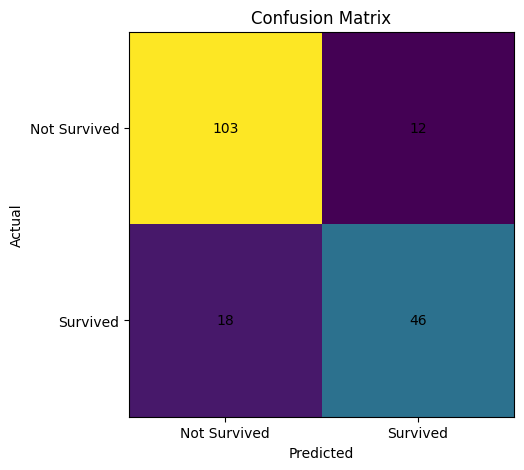

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.yticks([0, 1], ["Not Survived", "Survived"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Survived", "Survived"]
))

              precision    recall  f1-score   support

Not Survived       0.85      0.90      0.87       115
    Survived       0.79      0.72      0.75        64

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



In [ ]:
print("===== FINAL MODEL RESULTS =====")

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Survived", "Survived"]
))

===== FINAL MODEL RESULTS =====
Accuracy: 83.24 %

Confusion Matrix:
[[103  12]
 [ 18  46]]

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.85      0.90      0.87       115
    Survived       0.79      0.72      0.75        64

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



In [ ]:
import pickle

with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!
